In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

print(f"XGBoost versão: {xgb.__version__}")
print("Bibliotecas importadas")

XGBoost versão: 3.2.0
Bibliotecas importadas


In [3]:
df = pd.read_csv("PJME_hourly.csv")
display(df.head())

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")

print(df.dtypes)

print(df.isnull().sum())

# Conversão para datatime
df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.set_index("Datetime")
df = df.sort_index()

print(f"Período apresentado")
print(f"Início: {df.index.min()}")
print(f"Fim:    {df.index.max()}")
print(f"Total:  {len(df):,} registros horários")
print(f"Anos:   {df.index.min().year} a {df.index.max().year}")

print(f"\nEstatísticas de consumo (MW):")
print(df["PJME_MW"].describe().round(1))

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


Linhas: 145,366
Colunas: 2
Datetime        str
PJME_MW     float64
dtype: object
Datetime    0
PJME_MW     0
dtype: int64
Período apresentado
Início: 2002-01-01 01:00:00
Fim:    2018-08-03 00:00:00
Total:  145,366 registros horários
Anos:   2002 a 2018

Estatísticas de consumo (MW):
count    145366.0
mean      32080.2
std        6464.0
min       14544.0
25%       27573.0
50%       31421.0
75%       35650.0
max       62009.0
Name: PJME_MW, dtype: float64


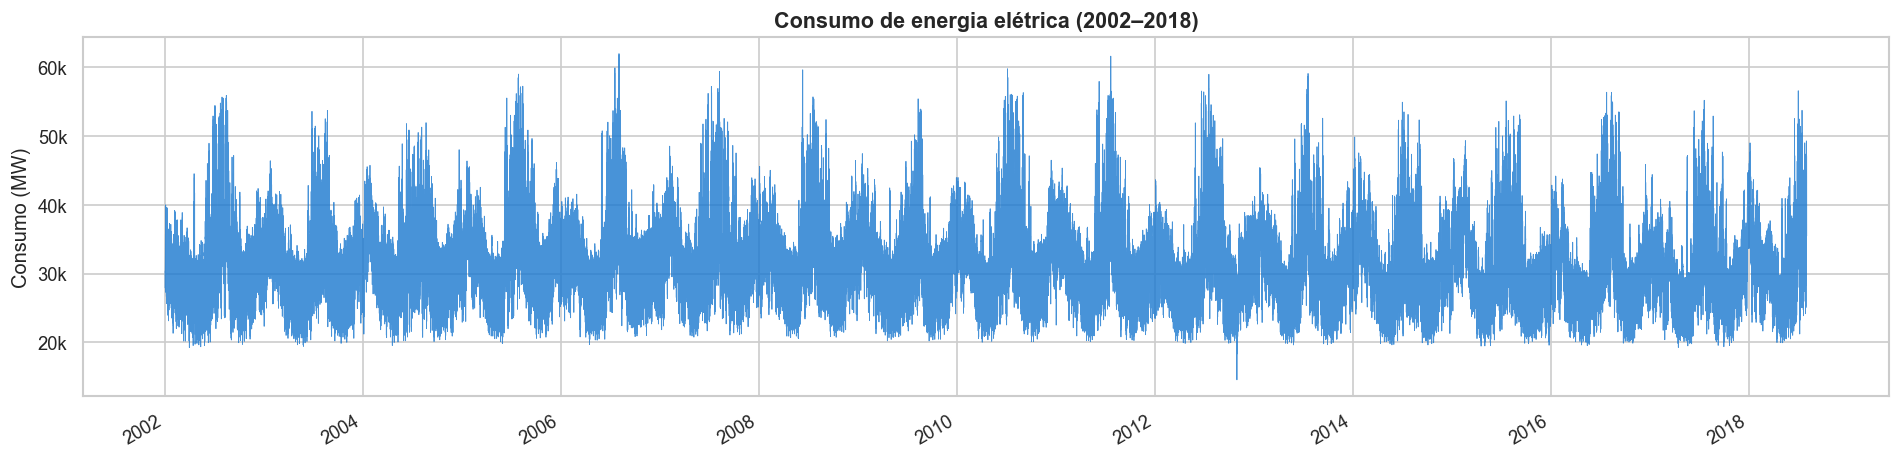

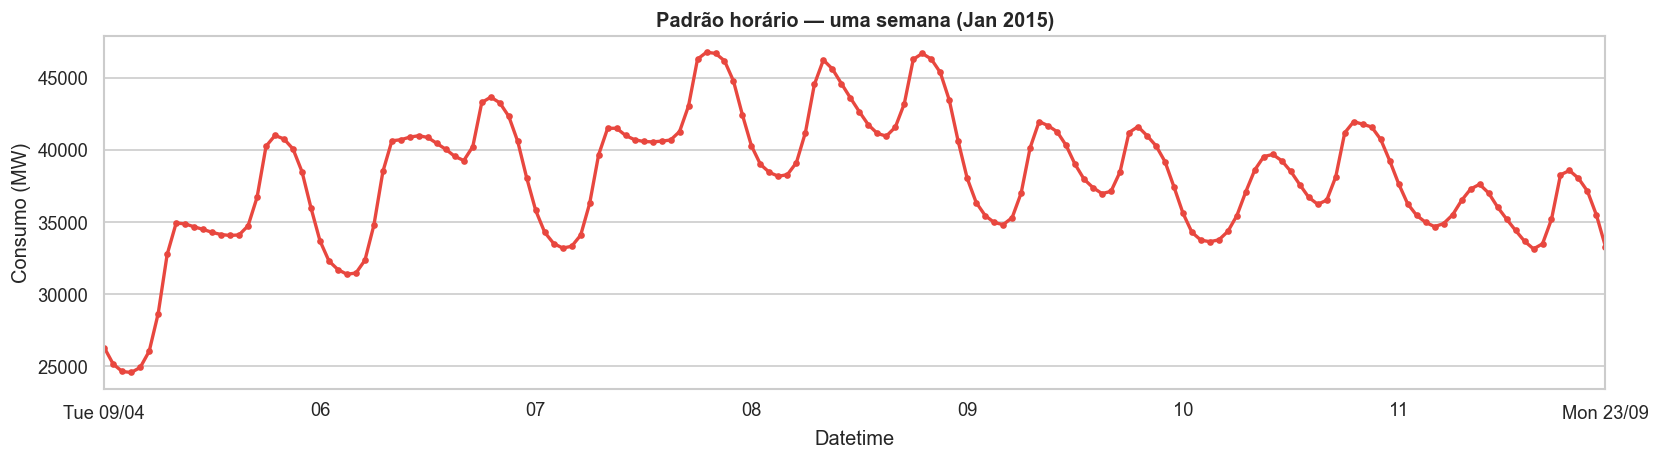

Decomposição sazonal


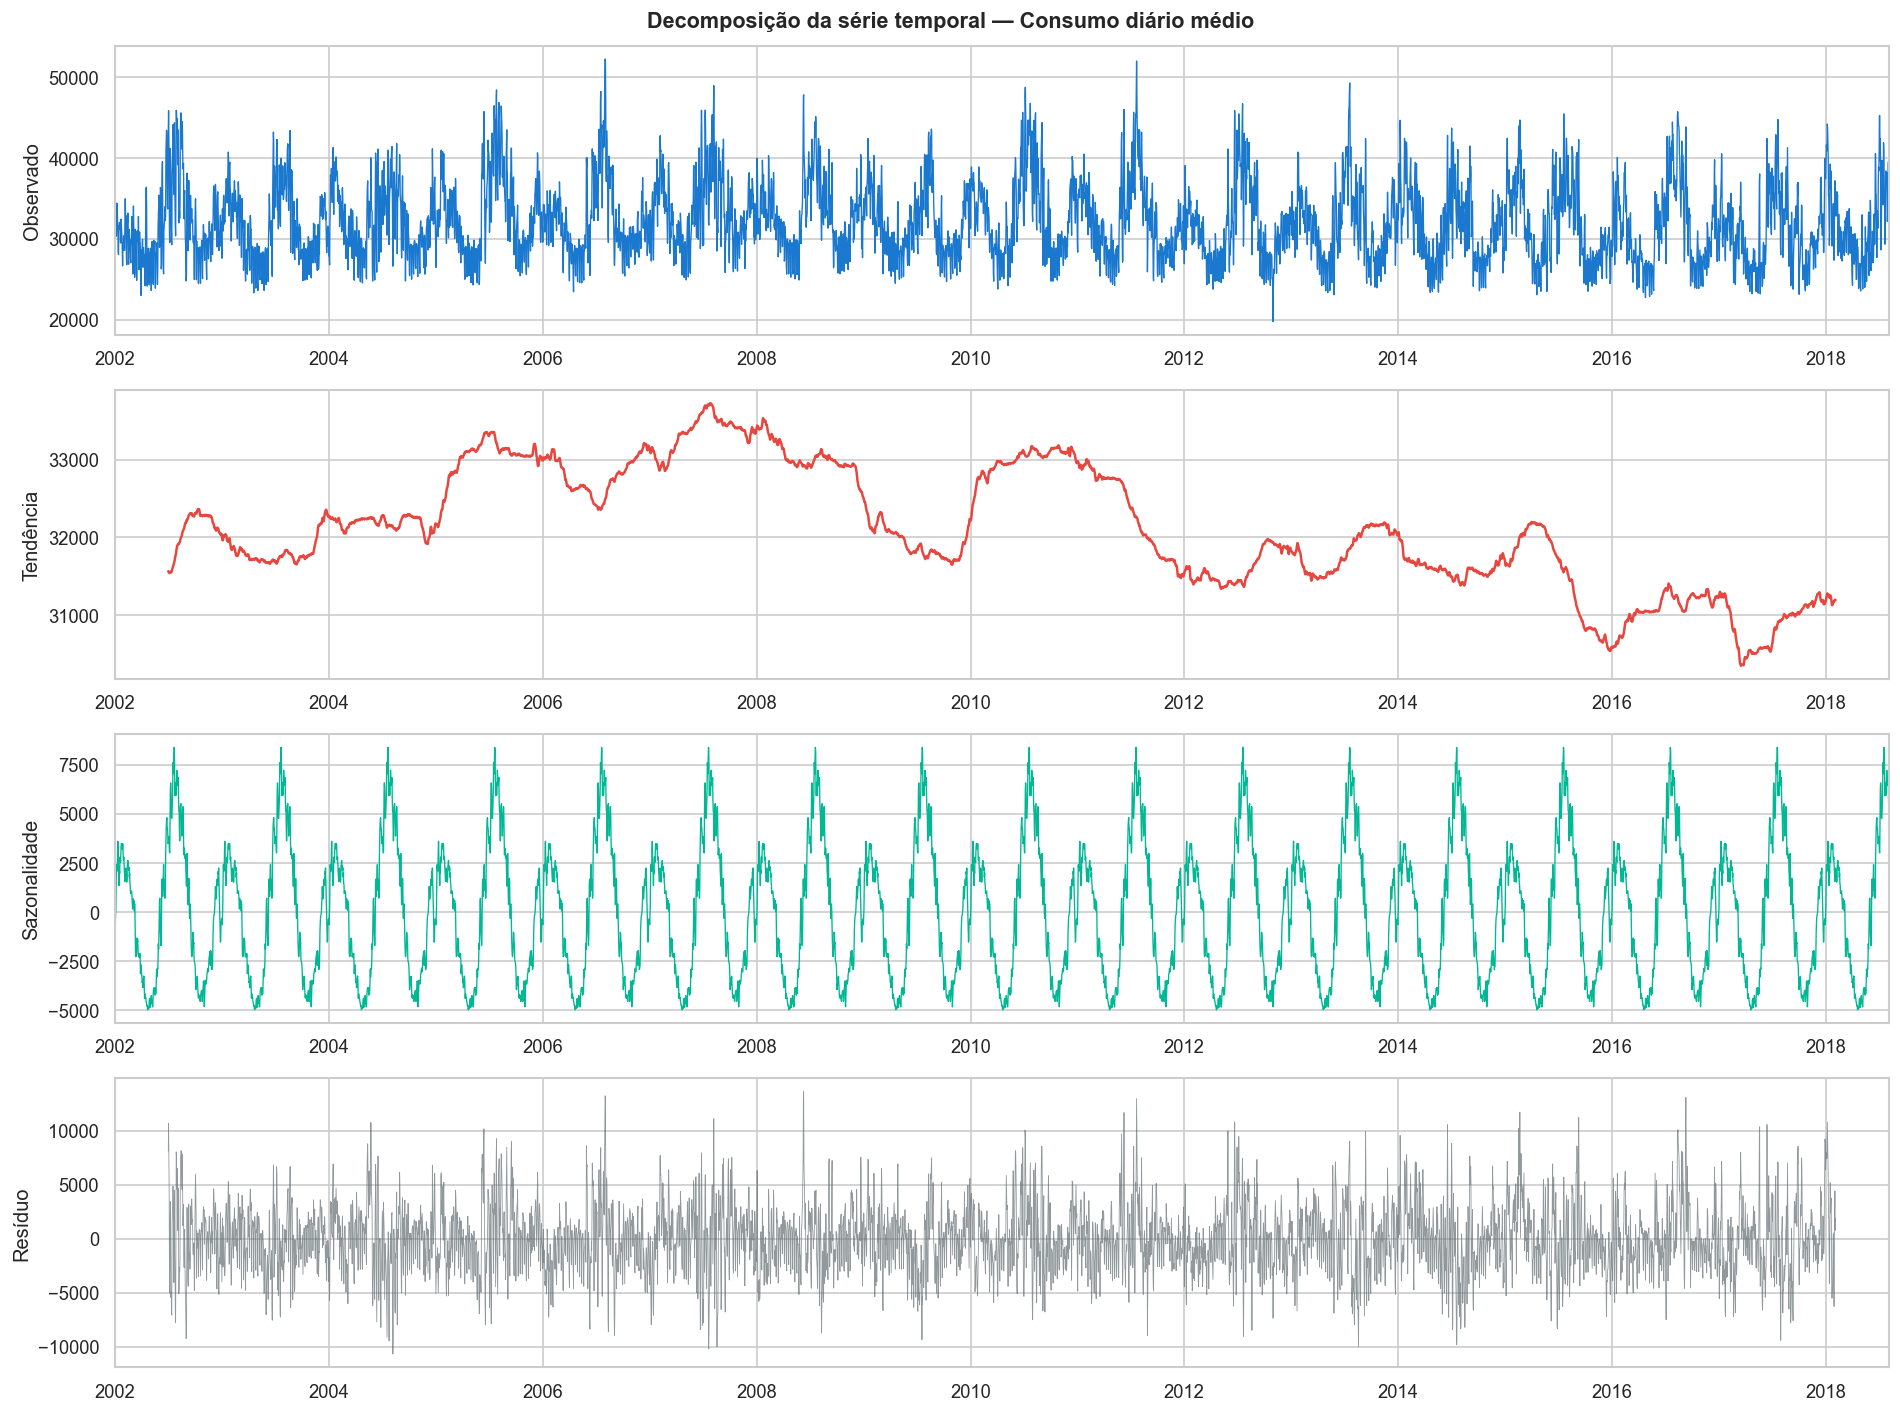

In [4]:
#visualização
fig, ax = plt.subplots(figsize=(16, 4))

df["PJME_MW"].plot(ax=ax, color="#1a78cf", linewidth=0.5, alpha=0.8)
ax.set_title("Consumo de energia elétrica (2002–2018)", 
             fontsize=13, fontweight="bold")
ax.set_ylabel("Consumo (MW)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.tight_layout()
plt.show()

#por semana
fig, ax = plt.subplots(figsize=(14, 4))

semana = df["2015-01-05":"2015-01-11"]
semana["PJME_MW"].plot(ax=ax, color="#e8473f", linewidth=2, marker="o", 
                        markersize=3)
ax.set_title("Padrão horário — uma semana (Jan 2015)", 
             fontsize=12, fontweight="bold")
ax.set_ylabel("Consumo (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d/%m"))
plt.tight_layout()
plt.show()

df_diario = df["PJME_MW"].resample("D").mean()

print("Decomposição sazonal")
decomposicao = seasonal_decompose(
    df_diario, 
    model="additive",    # tendência + sazonalidade + ruído
    period=365           # sazonalidade anual
)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle("Decomposição da série temporal — Consumo diário médio", 
             fontsize=13, fontweight="bold")

decomposicao.observed.plot(ax=axes[0], color="#1a78cf", linewidth=0.8)
axes[0].set_ylabel("Observado")

decomposicao.trend.plot(ax=axes[1], color="#e8473f", linewidth=1.5)
axes[1].set_ylabel("Tendência")

decomposicao.seasonal.plot(ax=axes[2], color="#00b894", linewidth=0.8)
axes[2].set_ylabel("Sazonalidade")

decomposicao.resid.plot(ax=axes[3], color="#636e72", linewidth=0.5, alpha=0.7)
axes[3].set_ylabel("Resíduo")

for ax in axes:
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [5]:
def criar_features_temporais(df):
    """
    Extrai features temporais do índice datetime.
    Cada feature captura um padrão diferente de sazonalidade.
    """
    df = df.copy()
    
    df["hora"]      = df.index.hour          # 0-23: padrão diário
    df["dia_semana"] = df.index.dayofweek    # 0=segunda, 6=domingo
    df["dia_mes"]   = df.index.day           # 1-31
    df["dia_ano"]   = df.index.dayofyear     # 1-365: posição no ano
    df["mes"]       = df.index.month         # 1-12: sazonalidade mensal
    df["trimestre"] = df.index.quarter       # 1-4: sazonalidade trimestral
    df["ano"]       = df.index.year          # tendência de longo prazo
    
    # Features derivadas, padrões comportamentais
    df["fim_semana"] = df["dia_semana"].isin([5, 6]).astype(int)
    df["hora_pico"]  = df["hora"].isin([7, 8, 9, 17, 18, 19]).astype(int)
    df["verao"]      = df["mes"].isin([6, 7, 8]).astype(int)
    df["inverno"]    = df["mes"].isin([12, 1, 2]).astype(int)
    
    # Features de lag — consumo nas horas anter
    df["lag_1h"]  = df["PJME_MW"].shift(1)   #1 hora atrás
    df["lag_24h"] = df["PJME_MW"].shift(24)  #24 horas atrás
    df["lag_168h"] = df["PJME_MW"].shift(168) #1 semana atrás
    
    # Médias p/ suavizar o ruído e capturar tendência local
    df["media_movel_24h"]  = df["PJME_MW"].shift(1).rolling(24).mean()
    df["media_movel_168h"] = df["PJME_MW"].shift(1).rolling(168).mean()
    
    return df

df_features = criar_features_temporais(df)

# Removendo linhas com NaN geradas pelos lags e médias móveis
df_features = df_features.dropna()

print(f"Features:")
print(f"Total de features: {df_features.shape[1] - 1}")
print(f"\nColunas:")
for col in df_features.columns:
    print(f"  {col}")

print(f"\nRegistros após remoção de NaN: {len(df_features):,}")

Features:
Total de features: 16

Colunas:
  PJME_MW
  hora
  dia_semana
  dia_mes
  dia_ano
  mes
  trimestre
  ano
  fim_semana
  hora_pico
  verao
  inverno
  lag_1h
  lag_24h
  lag_168h
  media_movel_24h
  media_movel_168h

Registros após remoção de NaN: 145,198


Divisão cronológica
Treino: 2002-01-08 → 2016-12-31
Teste:  2017-01-01 → 2018-08-03

Registros treino: 131,302 (90.4%)
Registros teste:  13,896 (9.6%)


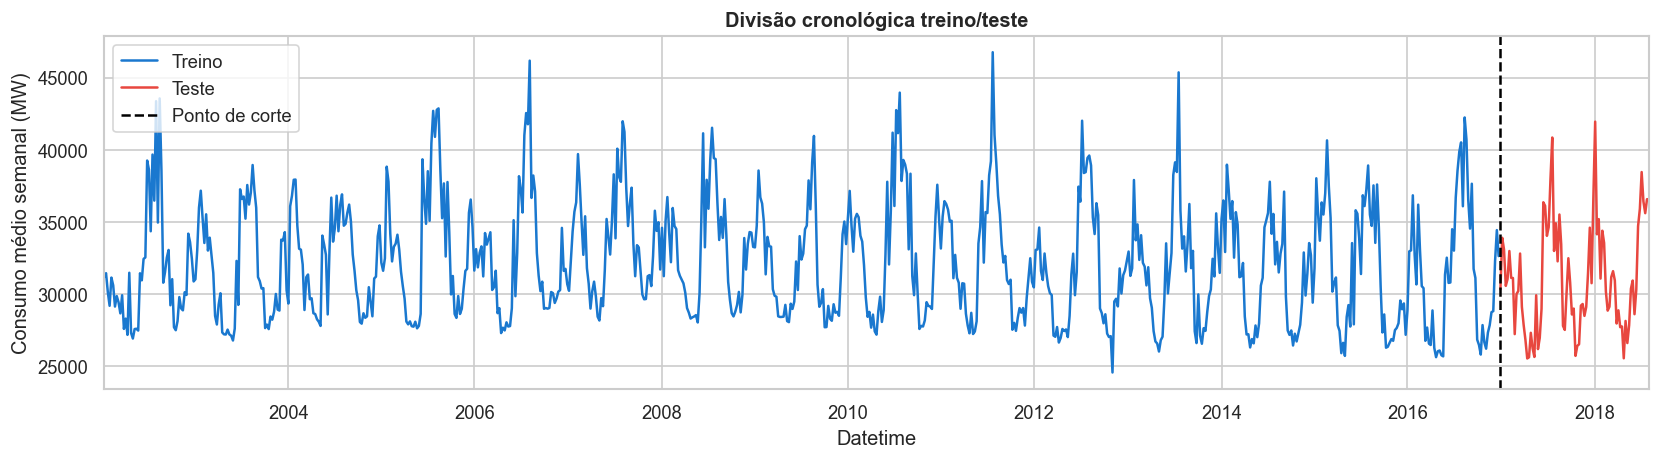

In [6]:
# Definindo features e target
FEATURES = ["hora", "dia_semana", "dia_mes", "dia_ano", "mes", 
            "trimestre", "ano", "fim_semana", "hora_pico", 
            "verao", "inverno", "lag_1h", "lag_24h", 
            "lag_168h", "media_movel_24h", "media_movel_168h"]

TARGET = "PJME_MW"

#últimos 12 meses pra teste
corte = "2017-01-01"

treino = df_features[df_features.index < corte]
teste  = df_features[df_features.index >= corte]

X_treino = treino[FEATURES]
y_treino = treino[TARGET]

X_teste = teste[FEATURES]
y_teste = teste[TARGET]

print(f"Divisão cronológica")
print(f"Treino: {treino.index.min().date()} → {treino.index.max().date()}")
print(f"Teste:  {teste.index.min().date()} → {teste.index.max().date()}")
print(f"\nRegistros treino: {len(treino):,} ({len(treino)/len(df_features)*100:.1f}%)")
print(f"Registros teste:  {len(teste):,} ({len(teste)/len(df_features)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(14, 4))

df_diario = df_features["PJME_MW"].resample("W").mean()
treino_vis = df_diario[df_diario.index < corte]
teste_vis  = df_diario[df_diario.index >= corte]

treino_vis.plot(ax=ax, color="#1a78cf", label="Treino", linewidth=1.5)
teste_vis.plot(ax=ax, color="#e8473f", label="Teste", linewidth=1.5)

ax.axvline(pd.Timestamp(corte), color="black", linestyle="--", 
           linewidth=1.5, label="Ponto de corte")
ax.set_title("Divisão cronológica treino/teste", fontweight="bold")
ax.set_ylabel("Consumo médio semanal (MW)")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
modelo = xgb.XGBRegressor(
    n_estimators=1000,       # número de árvores
    learning_rate=0.01,      # vel de aprendizado
    max_depth=6,             # profundidade máx de cada árvore
    min_child_weight=1,      # mín de amostras pra dividir um nó
    subsample=0.8,           # % dos dados usados em cada árvore
    colsample_bytree=0.8,    # % das features usadas em cada árvore
    random_state=42,
    n_jobs=-1                # usa todos os núcleos do processador
)

print("Treinando")

modelo.fit(
    X_treino, y_treino,
    eval_set=[(X_treino, y_treino), (X_teste, y_teste)],
    verbose=100   # mostra o progresso a cada 100 árvores
)

print("\nTreinamento concluído!")

Treinando
[0]	validation_0-rmse:6429.24177	validation_1-rmse:6165.13334
[100]	validation_0-rmse:2585.52043	validation_1-rmse:2532.82892
[200]	validation_0-rmse:1211.97741	validation_1-rmse:1239.93023
[300]	validation_0-rmse:785.68301	validation_1-rmse:839.09992
[400]	validation_0-rmse:645.65741	validation_1-rmse:703.75146
[500]	validation_0-rmse:578.77873	validation_1-rmse:636.96501
[600]	validation_0-rmse:534.76963	validation_1-rmse:591.60478
[700]	validation_0-rmse:503.26353	validation_1-rmse:559.71459
[800]	validation_0-rmse:478.79085	validation_1-rmse:536.08994
[900]	validation_0-rmse:457.48706	validation_1-rmse:515.52711
[999]	validation_0-rmse:440.56779	validation_1-rmse:499.53617

Treinamento concluído!


Métricas

MAE:   380 MW   (erro médio absoluto)
RMSE:  500 MW  (erro médio quadrático)
MAPE:  1.21%      (erro percentual médio)
R²:    0.9933         (variância explicada pelo modelo)


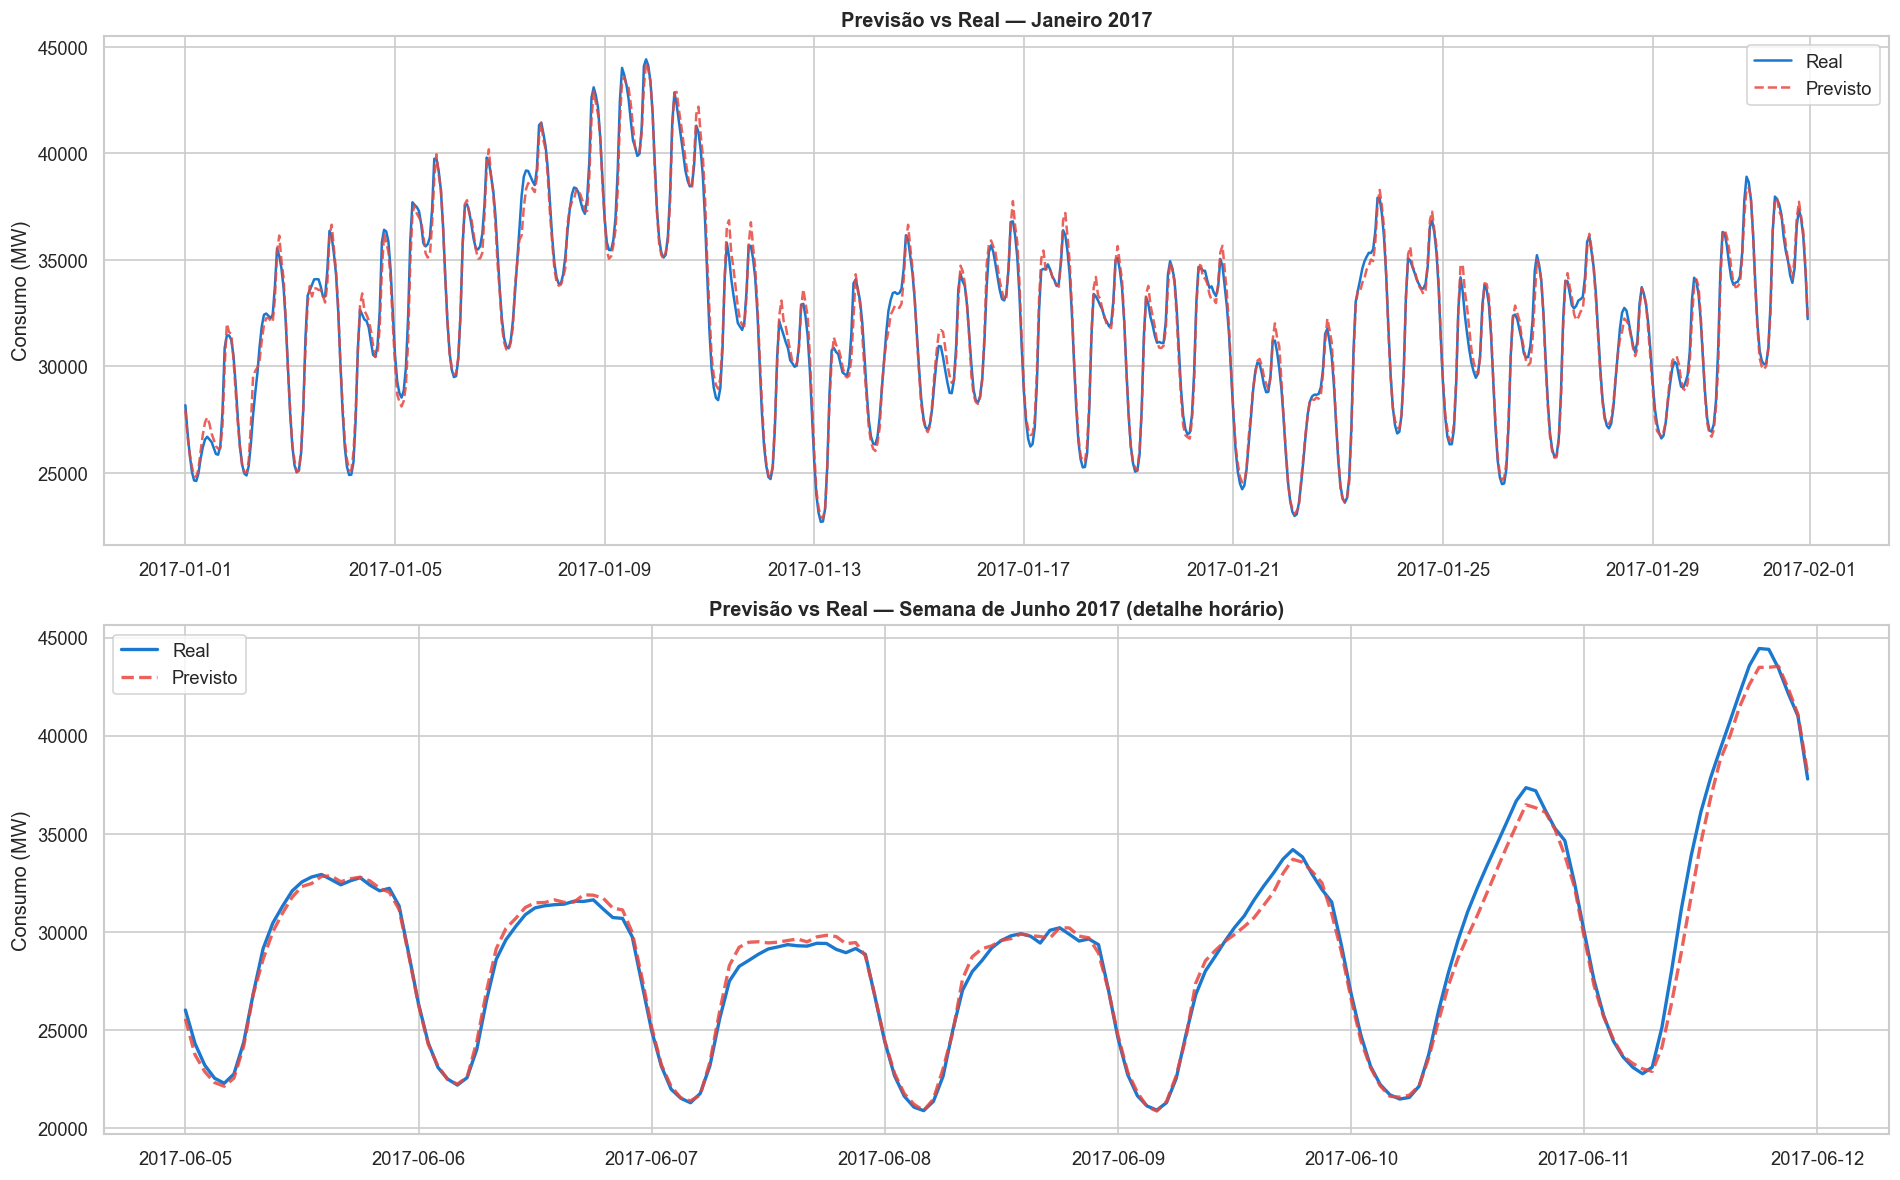

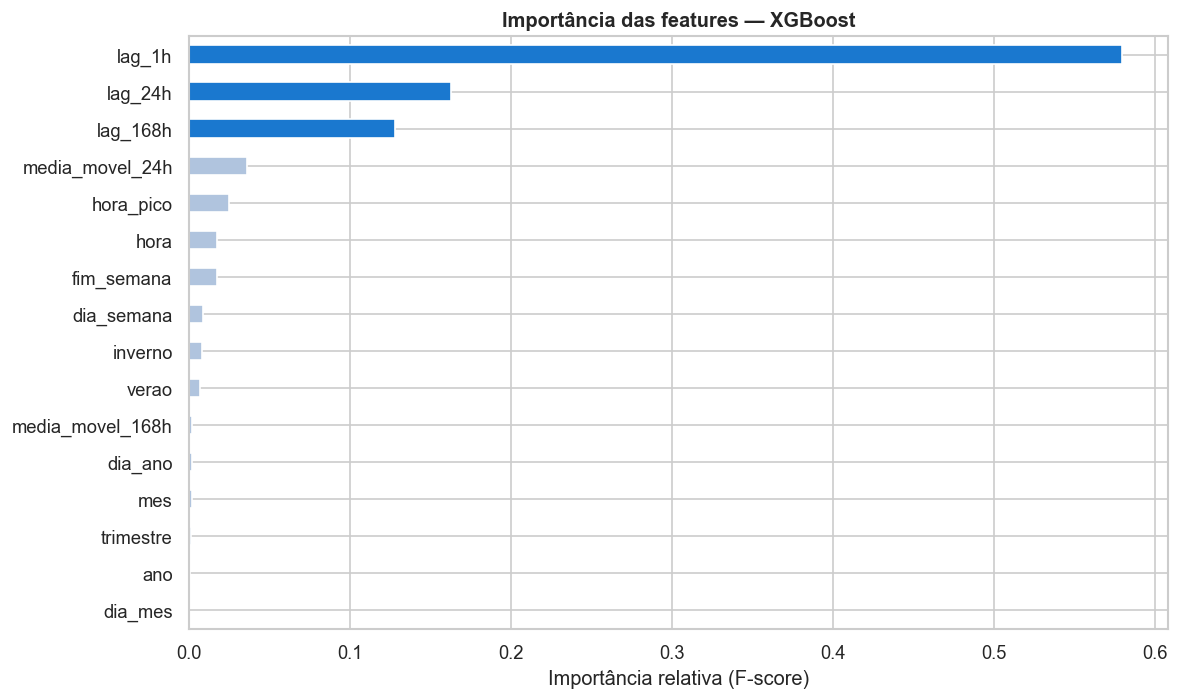

In [8]:
# Previsões no conjunto de teste
y_pred = modelo.predict(X_teste)

# Métricas
mae  = mean_absolute_error(y_teste, y_pred)
rmse = np.sqrt(mean_squared_error(y_teste, y_pred))
mape = np.mean(np.abs((y_teste - y_pred) / y_teste)) * 100
r2   = r2_score(y_teste, y_pred)

print("Métricas\n")
print(f"MAE:   {mae:,.0f} MW   (erro médio absoluto)")
print(f"RMSE:  {rmse:,.0f} MW  (erro médio quadrático)")
print(f"MAPE:  {mape:.2f}%      (erro percentual médio)")
print(f"R²:    {r2:.4f}         (variância explicada pelo modelo)")

#Previsões vs Real
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

#mês completo
mes_real = y_teste["2017-01-01":"2017-01-31"]
mes_pred = pd.Series(y_pred, index=y_teste.index)["2017-01-01":"2017-01-31"]

axes[0].plot(mes_real.index, mes_real.values, 
             color="#1a78cf", label="Real", linewidth=1.5)
axes[0].plot(mes_pred.index, mes_pred.values, 
             color="#e8473f", label="Previsto", linewidth=1.5, 
             linestyle="--", alpha=0.85)
axes[0].set_title("Previsão vs Real — Janeiro 2017", fontweight="bold")
axes[0].set_ylabel("Consumo (MW)")
axes[0].legend()

#uma semana pra ver o detalhe horário
semana_real = y_teste["2017-06-05":"2017-06-11"]
semana_pred = pd.Series(y_pred, index=y_teste.index)["2017-06-05":"2017-06-11"]

axes[1].plot(semana_real.index, semana_real.values, 
             color="#1a78cf", label="Real", linewidth=2)
axes[1].plot(semana_pred.index, semana_pred.values, 
             color="#e8473f", label="Previsto", linewidth=2, 
             linestyle="--", alpha=0.85)
axes[1].set_title("Previsão vs Real — Semana de Junho 2017 (detalhe horário)", 
                   fontweight="bold")
axes[1].set_ylabel("Consumo (MW)")
axes[1].legend()

plt.tight_layout()
plt.show()

#Importância das features
importancias = pd.Series(
    modelo.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
cores = ["#1a78cf" if i >= len(importancias) - 3 
         else "#b0c4de" for i in range(len(importancias))]
importancias.plot(kind="barh", ax=ax, color=cores, edgecolor="white")
ax.set_title("Importância das features — XGBoost", fontweight="bold")
ax.set_xlabel("Importância relativa (F-score)")
plt.tight_layout()
plt.show()

## ⚡ Conclusões do Projeto

### Padrões capturados:
O XGBoost, modelo utilizado, atingiu **MAPE de 1.21%** e **R² de 0.9933** no conjunto de teste, 
errando em média 380 MW, resultado bom considerando um consumo que varia entre 14.000 e 62.000 MW.
As previsões vs real mostram sobreposição quase perfeita nos ciclos diários e semanais.

### Preditor de passado recente:
As três features de lag respondem por +-86% da importância do modelo:
- **lag_1h** (57%) = o consumo é fortemente determinado pelo consumo 1 hora atrás;
- **lag_24h** (16%) — o mesmo horário do dia anterior;
- **lag_168h** (13%) — o mesmo horário da semana anterior.

Isso revela a **inércia do consumo de energia**, a demanda não muda bruscamente,ela evolui de forma contínua e previsível.

### Sazonalidade do Modelo:
A decomposição mostrou uma sazonalidade anual com amplitude de +-12.500 MW,
os verões americanos com ar condicionado no máximo vs as madrugadas de baixa demanda.
Esse padrão se repetiu de forma quase idêntica pelos 16 anos analisados.

### Intereferência por fatores externos:
O consumo cresceu até 2008, caiu com a crise financeira global e nunca voltou
ao pico anterior, provavelmente reflexo de maior eficiência energética e
mudanças na estrutura industrial da região PJM East.

### Divisão cronológica:
Usar dados futuros no treino (data leakage temporal) invalidaria completamentea avaliação. 
A divisão treino/teste foi feita respeitando a ordem cronológica do dataset,
treino até 2016, teste em 2017–2018 para garantir uma avaliação honesta.

---
*Análise realizada com 145.198 registros horários (2002–2018).*
*Dataset: Hourly Energy Consumption — PJM East (Kaggle)*
*Modelo: XGBoost com feature engineering temporal*

In [9]:
import joblib

joblib.dump(modelo, "energy_model.pkl")

# Salvando estatísticas históricas por hora, pro app comparar com a média
stats_hora = df.groupby(df.index.hour)["PJME_MW"].agg(["mean", "std"]).round(0)
stats_hora.to_csv("stats_hora.csv")

# Salvando médias por dia da semana
stats_dia = df.groupby(df.index.dayofweek)["PJME_MW"].mean().round(0)
stats_dia.to_csv("stats_dia.csv")

# Salvando médias por mês
stats_mes = df.groupby(df.index.month)["PJME_MW"].mean().round(0)
stats_mes.to_csv("stats_mes.csv")

# Salvando amostra dos dados históricos pra visualização
df_amostra = df["PJME_MW"].resample("D").mean().reset_index()
df_amostra.columns = ["data", "consumo_mw"]
df_amostra.to_csv("historico_diario.csv", index=False)

# Salvando os valores de lag necessários pro modelo prever
# Usamos os últimos valores reais conhecidos
ultimos_valores = {
    "lag_1h":  float(df["PJME_MW"].iloc[-1]),
    "lag_24h": float(df["PJME_MW"].iloc[-24]),
    "lag_168h": float(df["PJME_MW"].iloc[-168]),
    "media_movel_24h":  float(df["PJME_MW"].iloc[-24:].mean()),
    "media_movel_168h": float(df["PJME_MW"].iloc[-168:].mean())
}
joblib.dump(ultimos_valores, "ultimos_valores.pkl")

print("Arquivos salvos:")
print("  energy_model.pkl")
print("  stats_hora.csv")
print("  stats_dia.csv") 
print("  stats_mes.csv")
print("  historico_diario.csv")
print("  ultimos_valores.pkl")

Arquivos salvos:
  energy_model.pkl
  stats_hora.csv
  stats_dia.csv
  stats_mes.csv
  historico_diario.csv
  ultimos_valores.pkl
